BACKGROUND FIT

The goal of this section is to infer background normalization(s) and quantify uncertainties.
We shall also investigate how sensitive is the posterior probability to a difference in priors. 

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import trapezoid


In [36]:
bins = pd.read_csv('SourceData/s2_binning_info.csv')
resp_nr = pd.read_csv('SourceData/s2_response_nr.csv')
resp_er = pd.read_csv('SourceData/s2_response_er.csv')
bg = pd.read_csv('SourceData/er_and_cevns_background.csv')
events = pd.read_csv('SourceData/events_after_cuts.csv')

In [37]:
s2_bin_centers_log = bins['log_center_pe'].values
s2_bin_centers_lin = bins['linear_center_pe'].values
s2_bin_widths = (bins['end_pe'] - bins['start_pe']).values
s2_bin_edges = np.concatenate([bins['start_pe'].values, [bins['end_pe'].iloc[-1]]])

In [38]:
b_er = bg['er_background_events']
b_cevns = bg['cevns_background_events']
b_nominal = b_er + b_cevns
k_obs, _ = np.histogram(events['s2_area_pe'].values, bins=s2_bin_edges)

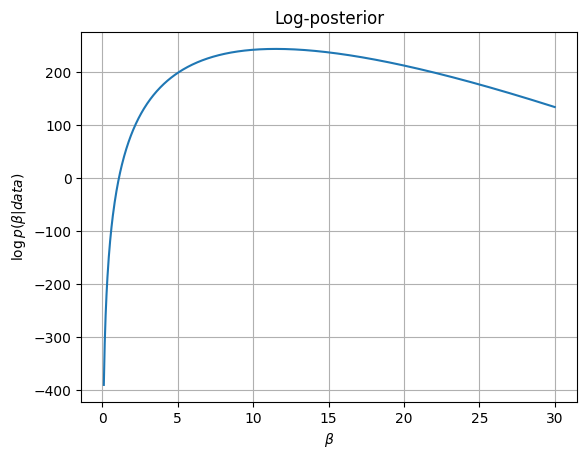

In [41]:
K_tot = np.sum(k_obs)
B_tot = np.sum(b_nominal)

#If we take the prior as being proportional to 1/beta, the log posterior distribution is the following:
def log_posterior(beta):
    return (K_tot - 1)*np.log(beta)-beta*B_tot
#Now let's sample the posterior for values of beta within the range of 0 and 30 and plot
beta_range = np.linspace(0.1,30,1000)
log_posterior_values = log_posterior(beta_range)

plt.figure()
plt.plot(beta_range, log_posterior_values)
plt.xlabel(r'$\beta$')
plt.ylabel(r'$\log p(\beta|data)$')
plt.title('Log-posterior')
plt.grid()
plt.show()



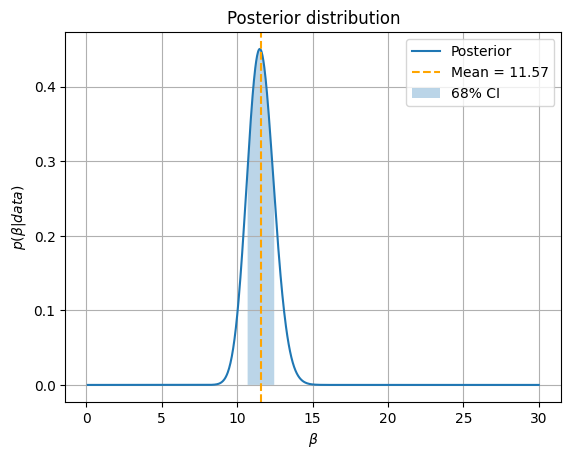

Mean β: 11.5715
68% credible interval: [10.6952, 12.4611]


In [46]:


posterior_unnorm = np.exp(log_posterior_values) #unnormalized posterior

# Normalize
evidence = trapezoid(posterior_unnorm, beta_range) # integrate over parameter space to get evidence
posterior = posterior_unnorm / evidence


plt.figure()
plt.plot(beta_range, posterior, label='Posterior')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$p(\beta|data)$')
plt.title('Posterior distribution')
plt.grid()

# Mean
mean_beta = trapezoid(beta_range * posterior, beta_range)

# CDF
cdf = np.cumsum(posterior) * (beta_range[1] - beta_range[0])

# 68% credible interval--> 0.68 = 0.84-0.16
low = beta_range[np.searchsorted(cdf, 0.16)] #Finds the position with 0.16 accumulated probability density
high = beta_range[np.searchsorted(cdf, 0.84)]#same but for 0.84

plt.axvline(mean_beta, color='orange', linestyle='--', label=f'Mean = {mean_beta:.2f}')
plt.fill_between(beta_range, posterior,
                 where=(beta_range >= low) & (beta_range <= high),
                 alpha=0.3, label='68% CI')
plt.legend()
plt.show()

print(f"Mean β: {mean_beta:.4f}")
print(f"68% credible interval: [{low:.4f}, {high:.4f}]")

Now let's see what happens when instead of a scale invariant prior we use a flat one. 

JAMES CODE GOES HERE